In [1]:
import zipfile
import os

# Update these paths as needed
zip_file_path = 'Kvasir-SEG.zip'
extracted_path = 'Kvasir-SEG'

# Extract the contents of the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

# List extracted folders
os.listdir(extracted_path)


['.DS_Store', 'Kvasir-SEG', 'images', 'kavsir_bboxes.json', 'masks']

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

import warnings
warnings.filterwarnings('ignore')


ModuleNotFoundError: No module named 'cv2'

In [ ]:
data_dir = 'Kvasir-SEG'
images_dir = os.path.join(data_dir, 'images')
masks_dir = os.path.join(data_dir, 'masks')


In [ ]:
# List all image filenames
image_filenames = os.listdir(images_dir)
image_filenames[:5]


['cju83yddek68q0850d2x7zfkm.jpg',
 'cju2mfjndoz700988b9lc3zeq.jpg',
 'cju7cq6su27qv075574dir0r3.jpg',
 'cju5g163vd6mt0817uccuga6u.jpg',
 'cju6wjm81vgsc0987enk9n3pr.jpg']

In [ ]:
def load_images_and_masks(images_dir, masks_dir, image_size=(256, 256)):
    images = []
    masks = []
    for filename in os.listdir(images_dir):
        img_path = os.path.join(images_dir, filename)
        mask_path = os.path.join(masks_dir, filename)

        if os.path.exists(img_path) and os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, image_size) / 255.0
            mask = cv2.resize(mask, image_size) / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

X, Y = load_images_and_masks(images_dir, masks_dir)
X.shape, Y.shape


((1000, 256, 256, 3), (1000, 256, 256, 1))

In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.1, random_state=42)


In [ ]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    b1 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    b1 = Conv2D(128, (3, 3), activation='relu', padding='same')(b1)

    u1 = UpSampling2D((2, 2))(b1)
    u1 = concatenate([u1, c3])
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(u1)
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    u2 = UpSampling2D((2, 2))(c4)
    u2 = concatenate([u2, c2])
    c5 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)
    c5 = Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    u3 = UpSampling2D((2, 2))(c5)
    u3 = concatenate([u3, c1])
    c6 = Conv2D(16, (3, 3), activation='relu', padding='same')(u3)
    c6 = Conv2D(16, (3, 3), activation='relu', padding='same')(c6)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c6)

    return Model(inputs=[inputs], outputs=[outputs])


In [ ]:
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=8, epochs=25)


2025-04-09 22:26:27.552203: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-04-09 22:26:27.552304: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-04-09 22:26:27.552329: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-04-09 22:26:27.552367: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-09 22:26:27.552393: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/25


ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 128, 128, 1), found shape=(None, 256, 256, 3)

In [ ]:
model.save_weights("segmentation.weights.h5")


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step


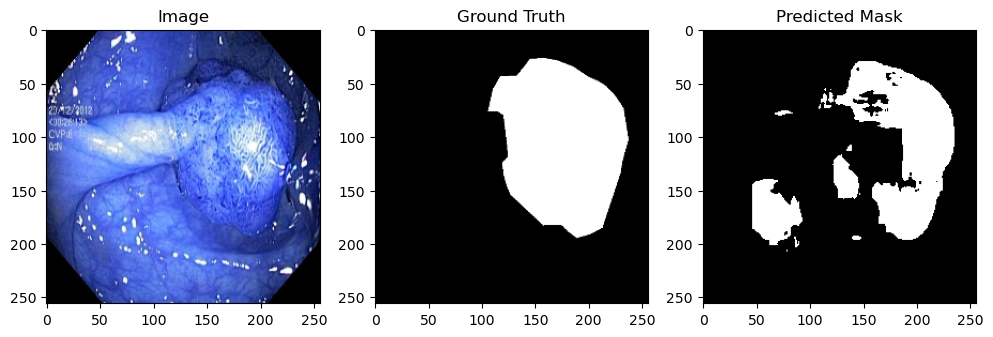

In [ ]:
preds = model.predict(X_val)

i = 0  # index of sample to view
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(X_val[i])
plt.title("Image")

plt.subplot(1, 3, 2)
plt.imshow(Y_val[i].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1, 3, 3)
plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
plt.title("Predicted Mask")
plt.show()


In [ ]:
# Evaluate the model on the validation set
evaluation_result = model.evaluate(X_test, y_test, verbose=1)
print("Loss:", evaluation_result[0])
print("Accuracy:", evaluation_result[1])


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 426ms/step - accuracy: 0.8459 - loss: 0.4899
Loss: 0.46379712224006653
Accuracy: 0.8505647778511047


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define desired dimensions (adjust these based on your model's input size)
desired_width = 256
desired_height = 256

def preprocess_single_image(image_path):
    # Check if the file exists
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found at: {image_path}")
    
    # Load and preprocess the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image from {image_path}. Check file integrity or path.")
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (desired_width, desired_height))  # Resize to model input size
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

def make_prediction(model, image_path):
    # Preprocess the single image
    input_image = preprocess_single_image(image_path)

    # Expand dimensions to create batch-like shape (1, height, width, channels)
    input_image = np.expand_dims(input_image, axis=0)

    # Make prediction
    prediction = model.predict(input_image)[0]  # [0] to remove batch dimension
    return prediction

# Example usage
image_path = '/Users/madhav_limbasiya/Documents/code/Kvasir-SEG/images/cju0u2g7pmnux0801vkk47ivj.jpg'
try:
    prediction = make_prediction(model, image_path)

    # Visualize the input image and the model prediction with a color map
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(preprocess_single_image(image_path))
    plt.title('Input Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(prediction[:, :, 0], cmap='viridis')
    plt.title('Model Prediction')
    plt.axis('off')

    plt.show()
except Exception as e:
    print(f"Error: {e}")

Error: name 'model' is not defined


In [ ]:
# Save the model
# model.save('/Users/bhavyapatamsetti/Desktop/code')

import tensorflow as tf
from tensorflow import keras

# Define or load a model
# model = keras.Sequential([
#     keras.layers.Dense(64, activation='relu', input_shape=(10,)),
#     keras.layers.Dense(1, activation='sigmoid')
# ])

model = load_model("model.keras")

# Compile the model (optional but recommended)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Save the model
model.save('/Users/madhav_limbasiya/Documents/code/model.keras')  # Saving as .h5 format


NameError: name 'load_model' is not defined

In [ ]:
!streamlit run main.py